In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../climate/pre_dataset/file1f43b983122_lat=52.25_lng=5.5_period=20000501-20240917.csv", sep=",", skiprows=11)

# Convert datetime column to datetime format
df['datetime_lst'] = pd.to_datetime(df['datetime_lst'])

# Calculate daily mean and max temperatures
daily_max_temp = df.groupby(df['datetime_lst'].dt.date)['t2m'].max()

# Filter days where mean temp >= 15°C
daily_mean_temp = df.groupby(df['datetime_lst'].dt.date)['t2m'].mean()
valid_days = daily_mean_temp[daily_mean_temp >= 18].index

# Create three filtered datasets based on max temperature ranges
range_20_25 = daily_max_temp[(daily_max_temp >= 20) & (daily_max_temp < 25)].index
range_25_30 = daily_max_temp[(daily_max_temp >= 25) & (daily_max_temp < 30)].index
range_above_30 = daily_max_temp[daily_max_temp >= 30].index

# Intersection with valid days (mean temp >= 15)
range_20_25 = valid_days.intersection(range_20_25)
range_25_30 = valid_days.intersection(range_25_30)
range_above_30 = valid_days.intersection(range_above_30)

# Filter datasets
df_20_25 = df[df['datetime_lst'].dt.date.isin(range_20_25)]
df_25_30 = df[df['datetime_lst'].dt.date.isin(range_25_30)]
df_above_30 = df[df['datetime_lst'].dt.date.isin(range_above_30)]

# Save datasets to CSV files
df_20_25.to_csv("climate/pre_dataset/temp_20_25.csv", index=False)
df_25_30.to_csv("climate/pre_dataset/temp_25_30.csv", index=False)
df_above_30.to_csv("climate/pre_dataset/temp_above_30.csv", index=False)


In [4]:
# Function to filter dataset and create a copy
def filter_dataset(df, days):
    filtered_df = df[df['datetime_lst'].dt.date.isin(days)].copy()
    return filtered_df

# Function to plot heatmap and save as PNG
def plot_heatmap(df, title, filename, vmin, vmax, height):
    df.loc[:, 'hour'] = df['datetime_lst'].dt.hour
    df.loc[:, 'date'] = df['datetime_lst'].dt.date

    pivot_table = df.pivot_table(values='t2m', index='date', columns='hour', aggfunc='mean')

    plt.figure(figsize=(14, height))
    ax = sns.heatmap(pivot_table, cmap="coolwarm", cbar_kws={'label': 'Temperature (°C)'}, linewidths=0.1, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the heatmap
    plt.savefig(f"climate/{filename}.png", dpi=300)
    plt.close()
    print(f"Saved {filename}.png")

# Plot and save each dataset
plot_heatmap(df_20_25, "Heatmap for Max Temp between 20-25°C", "heatmap_20_25", 15, 25, 40)
plot_heatmap(df_25_30, "Heatmap for Max Temp between 25-30°C", "heatmap_25_30", 15, 30, 30)
plot_heatmap(df_above_30, "Heatmap for Max Temp above 30°C", "heatmap_above_30", 15, 40, 25)

Saved heatmap_20_25.png
Saved heatmap_25_30.png
Saved heatmap_above_30.png



mean percentile for "t2m" on "Warm day (20–25°C)":
hour
0     16.477899
1     16.171377
2     15.916486
3     15.713768
4     15.627355
5     16.027355
6     17.015217
7     18.153986
8     19.292935
9     20.244203
10    21.152536
11    21.763043
12    22.177355
13    22.470290
14    22.590580
15    22.453261
16    22.087681
17    21.480435
18    20.578804
19    19.372645
20    18.060870
21    17.221196
22    16.577174
23    16.816667

mean percentile for "ssrd" on "Warm day (20–25°C)":
hour
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       1.682971
5      27.635870
6      95.856884
7     188.521739
8     295.246377
9     397.981884
10    477.969203
11    525.047101
12    537.840580
13    524.661232
14    479.384058
15    407.693841
16    321.485507
17    223.222826
18    127.483696
19     48.733696
20      6.722826
21      0.000000
22      0.000000
23      0.000000

mean percentile for "dhi" on "Warm day (20–25°C)":
hour
0       0.000000
1       0.000000
2 

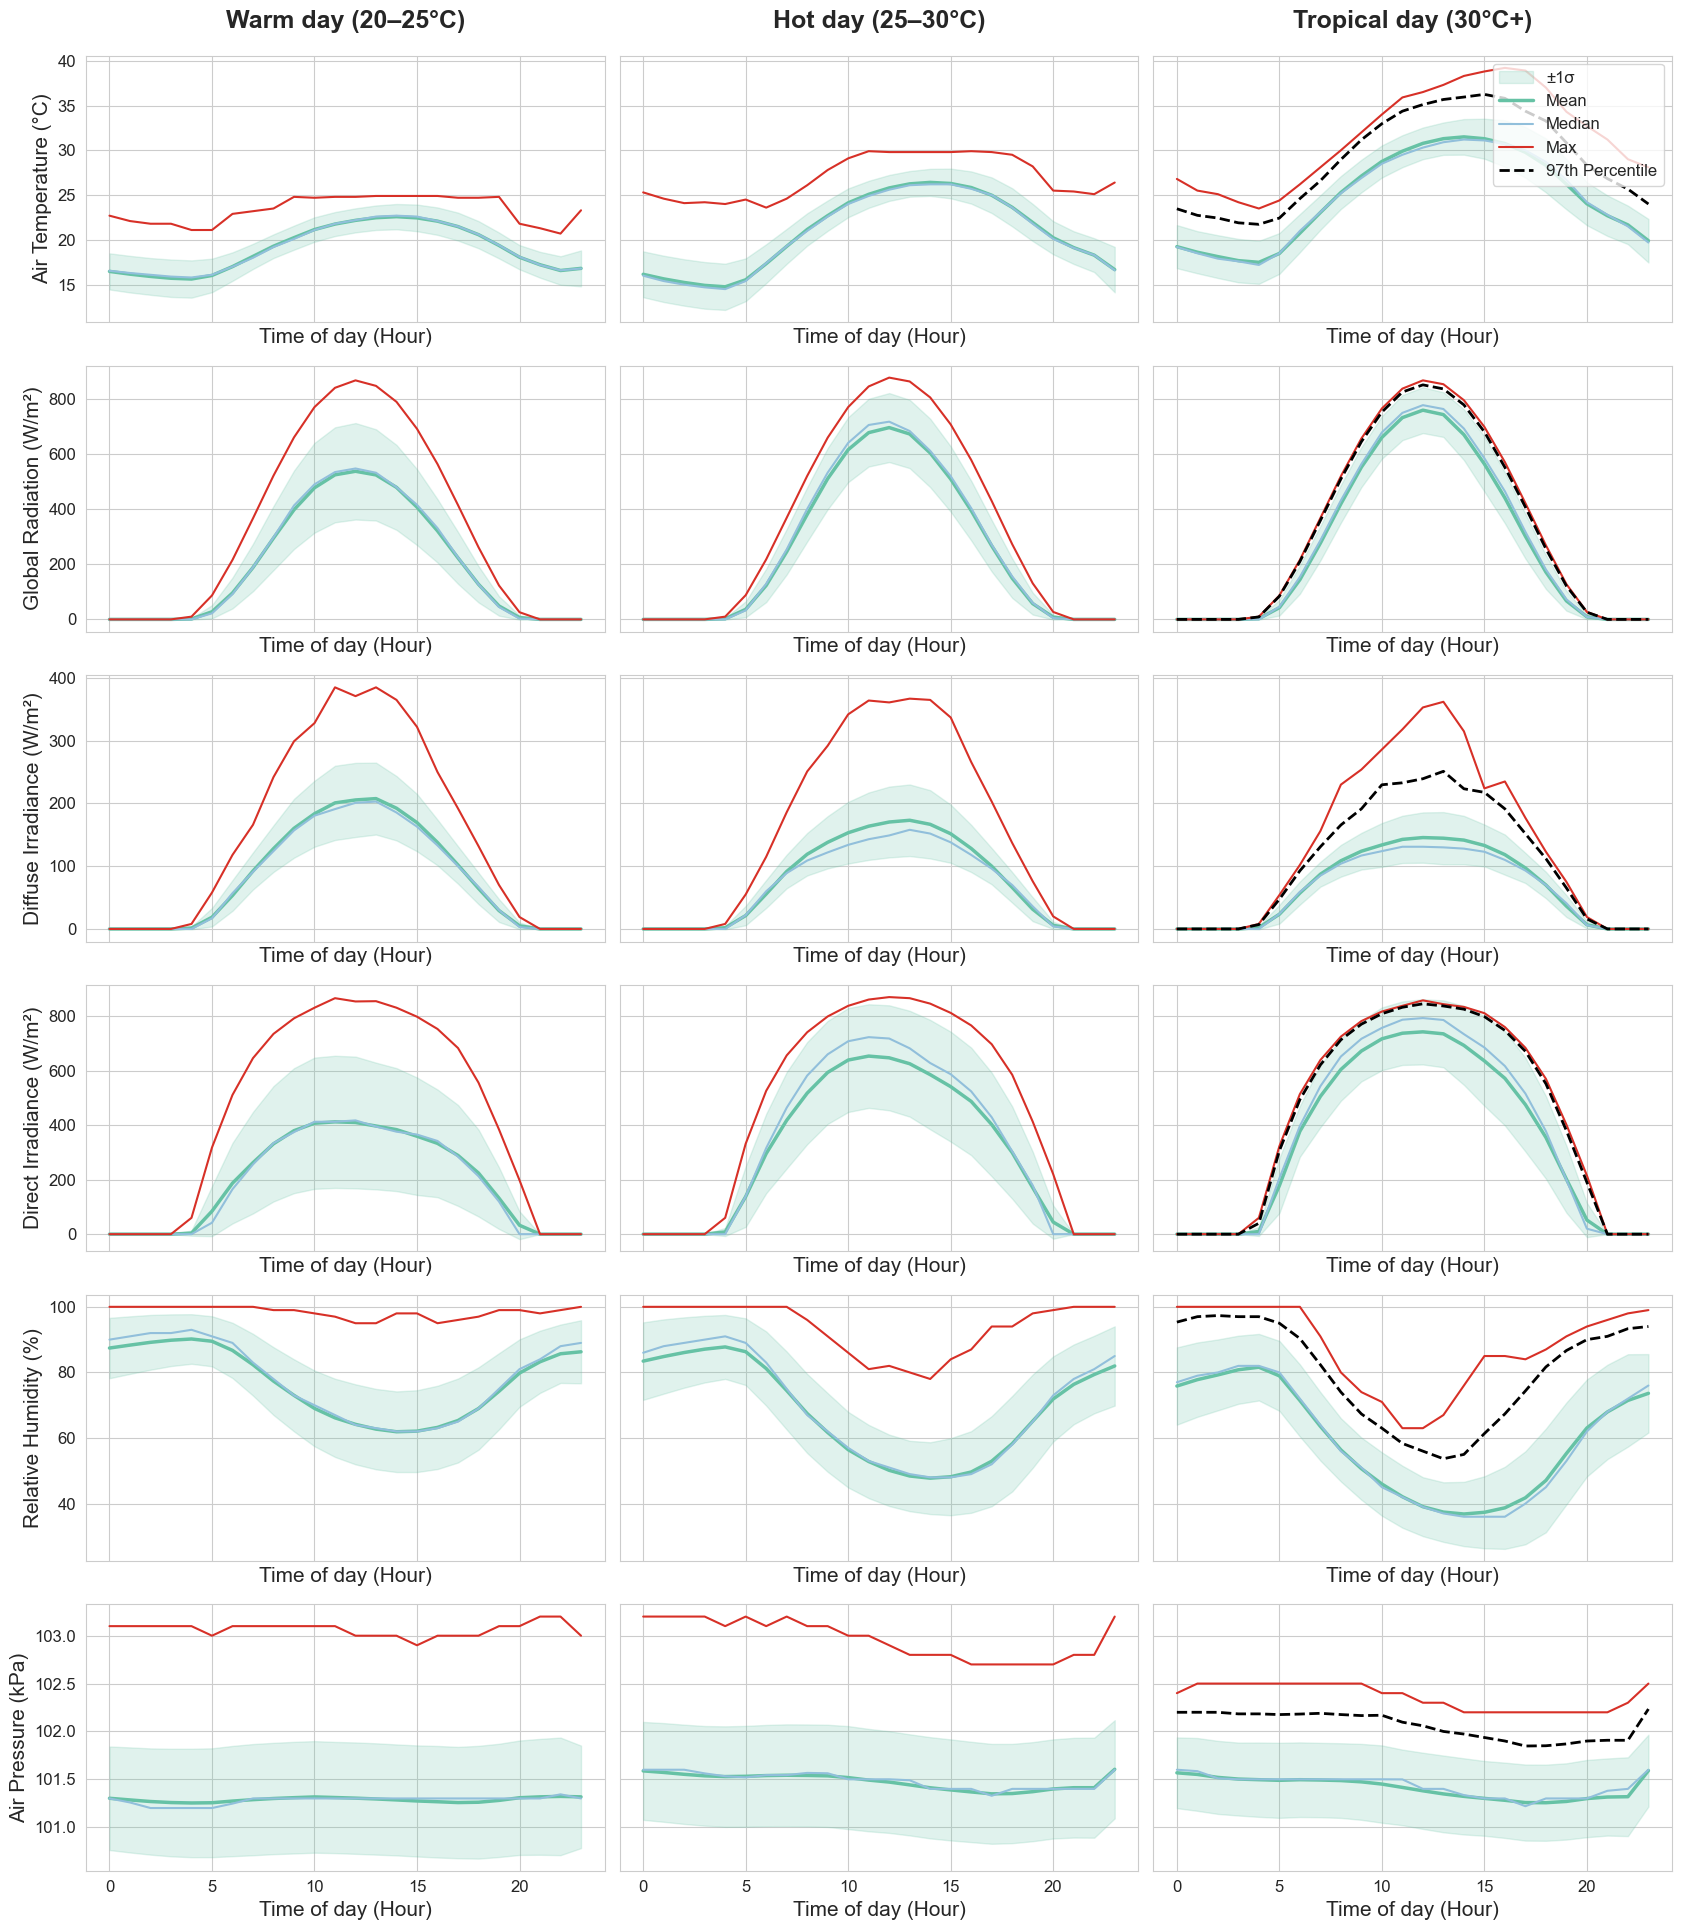

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Filepaths for the three day types
files = {
    'Warm day (20–25°C)': 'climate/pre_dataset/temp_20_25.csv',
    'Hot day (25–30°C)': 'climate/pre_dataset/temp_25_30.csv',
    'Tropical day (30°C+)': "climate/pre_dataset/temp_above_30.csv"
}

# Variables to plot: column name → y-axis label
variables = {
    't2m': 'Air Temperature (°C)',
    'ssrd': 'Global Radiation (W/m²)',
    'dhi': 'Diffuse Irradiance (W/m²)',
    'dni': 'Direct Irradiance (W/m²)',
    'r2m': 'Relative Humidity (%)',
    'sp': 'Air Pressure (kPa)'
}

import pandas as pd
import matplotlib.pyplot as plt

# Color mapping
colors = {
    '50%': '#91bfdb',       # Median
    'mean': '#66c2a5',      # Mean
    '97%': '#000000',       # 97.5th percentile
    'max': '#d73027'        # Max
}

# Compute statistics
stats = {}
for label, file in files.items():
    df = pd.read_csv(file, parse_dates=['datetime'])
    df['hour'] = df['datetime'].dt.hour
    stats[label] = {}

    for var in variables:
        grouped = df.groupby('hour')[var]
        hourly = grouped.agg(['mean', 'std', 'median', 'max'])

        # Compute 97.5th percentile manually
        p97 = grouped.quantile(0.97)
        hourly['97%'] = p97

        # Unit conversion
        if var == 'sp':
            hourly = hourly / 1000
        if var == 'r2m':
            hourly = hourly * 100

        # Save to dictionary
        stats[label][var] = hourly

        # Print 97.5th percentile values
        print(f'\nmean percentile for "{var}" on "{label}":')
        print(hourly["mean"].to_string())

# Plot setup
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 20), sharex=True, sharey='row')
fig.subplots_adjust(hspace=0.3, wspace=0.1)

font_title = 18
font_label = 15
font_ticks = 12

# Column titles
for col_idx, label in enumerate(files.keys()):
    axes[0, col_idx].set_title(label, fontsize=font_title, pad=20, fontweight='bold')

# Plotting
for row_idx, (var, ylabel) in enumerate(variables.items()):
    for col_idx, (day_label, stat_dict) in enumerate(stats.items()):
        ax = axes[row_idx, col_idx]
        data = stat_dict[var]

        mean = data['mean']
        std = data['std']

        # ±1σ shaded region
        ax.fill_between(data.index, mean - std, mean + std,
                        color=colors['mean'], alpha=0.2, label='±1σ')

        # Main lines
        ax.plot(data.index, mean, color=colors['mean'], label='Mean', linewidth=2.5)
        ax.plot(data.index, data['median'], color=colors['50%'], label='Median', linewidth=1.5)
        ax.plot(data.index, data['max'], color=colors['max'], label='Max', linewidth=1.5)
        if day_label == 'Tropical day (30°C+)' and '97%' in data.columns:
            ax.plot(data.index, data['97%'], color=colors['97%'],
                    label='97th Percentile', linestyle='--', linewidth=2.0)

        # 97.5th percentile
        # if '97%' in data.columns:
        #     ax.plot(data.index, data['97%'], color=colors['97%'],
        #             label='97th Percentile', linestyle='--', linewidth=2.0)

        ax.set_xlabel('Time of day (Hour)', fontsize=font_label)
        ax.tick_params(axis='both', labelsize=font_ticks)
        ax.grid(True)

        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=font_label)

        if row_idx == 0 and col_idx == 2:
            ax.legend(loc='upper right', fontsize=font_ticks)

plt.tight_layout(rect=[0.06, 0.03, 1, 1])
plt.show()
